In [1]:
import numpy as np
import pandas as pd 

X_train = pd.read_csv('../data/X_train.csv')
y_train = pd.read_csv('../data/y_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv')

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, max_error, mean_squared_log_error, r2_score
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import cross_val_score
import pickle

model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
maxerr = max_error(y_test, y_pred)

C:\Users\thouf\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [2]:
error_df = pd.DataFrame({
    "error name": ["MAE", "MSE", "RMSE", "Max Error", "RMSLE"],
    "value": [mae, mse, rmse, maxerr, rmse]
})

print("Error Metrics:")
error_df

r2 = r2_score(y_test, y_pred)
n = X_test.shape[0]  # number of samples
k = X_test.shape[1]  # number of features
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

Error Metrics:


In [3]:
accuracy_df = pd.DataFrame({
    "accuracy name": ["R Square", "Adjusted R Square"],
    "value": [r2, adj_r2]
})

print("\nAccuracy Metrics:")
accuracy_df

y_pred_flat = y_pred.flatten()
y_test_flat = np.array(y_test).flatten()
mlr_diff = pd.DataFrame({'Actual value': y_test_flat, 'Predicted value': y_pred_flat})
mlr_diff.head()

residuals = y_test_flat - y_pred_flat


Accuracy Metrics:


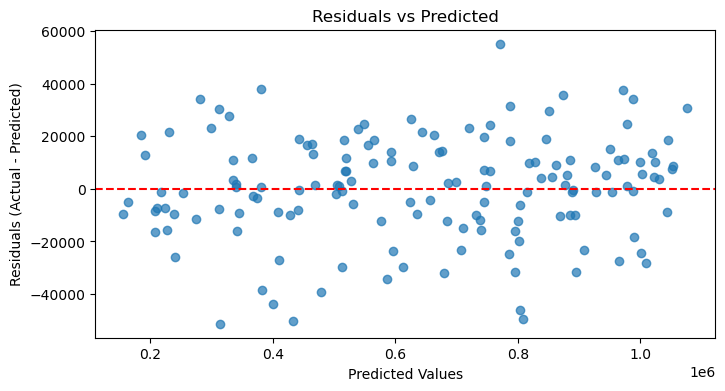

In [6]:
plt.figure(figsize=(8,4))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predicted")
plt.show()

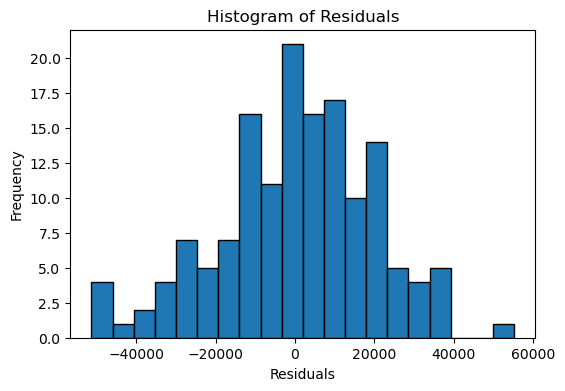

In [7]:
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=20, edgecolor='k')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

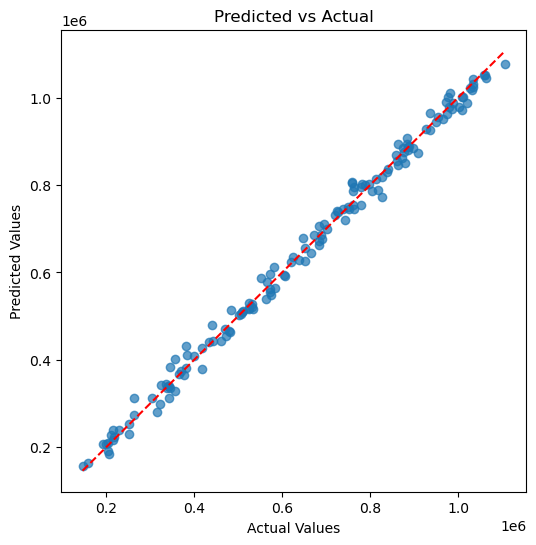

In [8]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # y=x line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual")
plt.show()

In [9]:
# Predictions and scores
y_train_pred = model.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_pred)

In [10]:
# Create DataFrame
r2_df = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'R^2 Score': [train_r2, test_r2]
})

r2_df

with open('rf_regression_model.sav', 'wb') as f:
    pickle.dump(model, f)

print("Model saved as 'rf_regression_model.sav'")

Model saved as 'rf_regression_model.sav'


In [11]:
import pickle

with open('rf_regression_model.sav', 'wb') as f:
    pickle.dump(model, f)

print("Model saved successfully")

Model saved successfully


In [12]:
print(model)

RandomForestRegressor(random_state=42)
